# Week 4 Day 1: Problem Definition & Quick EDA

## Task 1: Problem Definition & Success Metric

**Target Definition:** `income >50K` = Positive Class (1), `income <=50K` = Negative Class (0).

**Business Objective:** Maximize the precision among contacted users to avoid wasted outreach. If a marketing campaign involves a cost to contact individuals, we want to ensure that those we predict as high-income actually are high-income.

**Base Rate:** The base rate of the positive class (>50K) in the Adult dataset is approximately 23.93%.

**Primary Evaluation Metric:** **Precision**.
*Trade-off Explanation:* We choose Precision over Recall because our goal is to minimize false positives (wasted outreach costs). While focusing on Precision means we might miss some true high-income individuals (lower Recall), it ensures a high ROI for the marketing budget by targeting only those highly likely to be in the >50K bracket.


In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Adult dataset
print("Fetching dataset...")
data = fetch_openml('adult', version=2, as_frame=True)
df = data.frame

# 2. Convert target to binary 0/1
# In version 2, the target column is usually 'class' and values are '>50K', '<=50K'
target_col = 'class'
df[target_col] = df[target_col].apply(lambda x: 1 if x == '>50K' else 0).astype(int)

# Calculate Base Rate (printing for confirmation)
base_rate = df[target_col].mean() * 100
print(f"Base Rate (Positive Class): {base_rate:.2f}%")

# 3. Clean missing values (Dataset uses '?' -> NaN)
df.replace('?', np.nan, inplace=True)

df.head()


Fetching dataset...
Base Rate (Positive Class): 23.93%


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [4]:
# 4. Basic EDA

# Data shape
print(f"Data Shape: {df.shape}\n")

# Column types
print("Column Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Numeric summaries
print("Numeric Summaries:")
display(df.describe())
print("\n" + "="*50 + "\n")

# Value counts for categorical columns
categorical_cols = df.select_dtypes(include=['category', 'object']).columns
for col in categorical_cols:
    print(f"Value Counts for {col}:")
    display(df[col].value_counts(dropna=False))
    print("\n")


Data Shape: (48842, 15)

Column Types:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class                int64
dtype: object


Numeric Summaries:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,class
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000




Value Counts for workclass:


workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64



Value Counts for education:


...

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64



Value Counts for sex:


sex
Male      32650
Female    16192
Name: count, dtype: int64



Value Counts for native-country:


native-country
United-States                 43832
Mexico                          951
NaN                             857
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

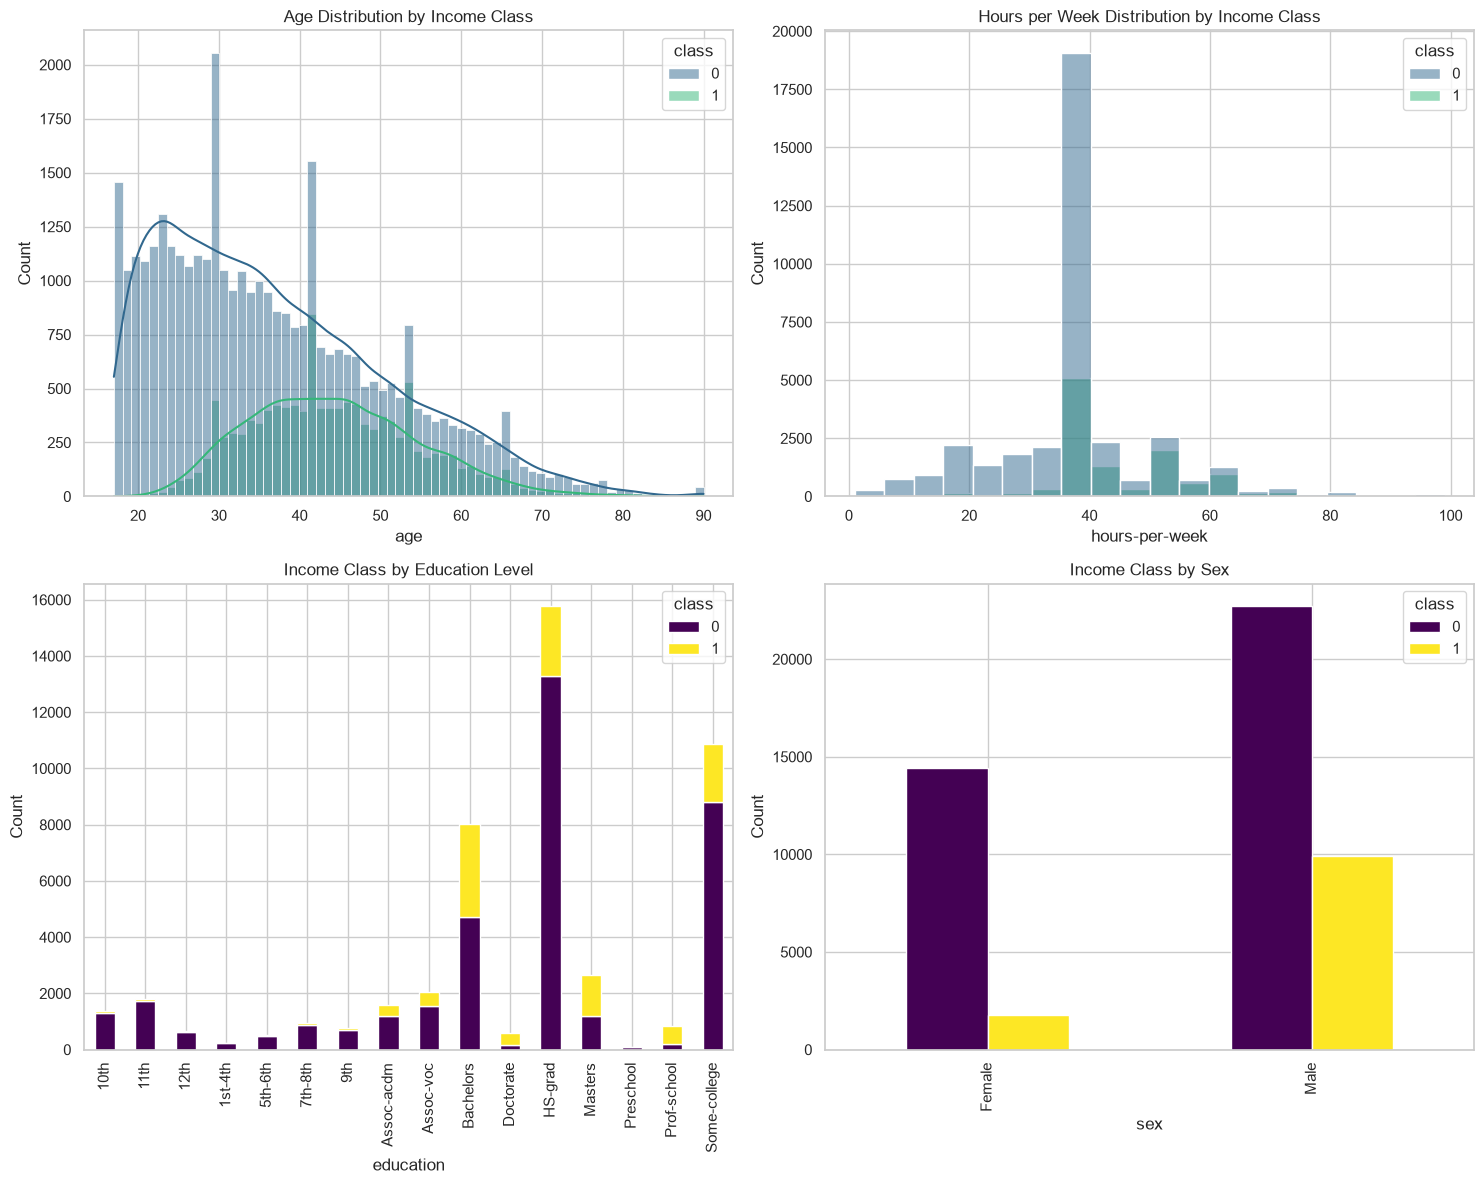

In [5]:
# 5. Visualizations

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Histogram: Age
sns.histplot(data=df, x='age', hue='class', kde=True, ax=axes[0,0], palette="viridis")
axes[0,0].set_title('Age Distribution by Income Class')

# Histogram: Hours per week
sns.histplot(data=df, x='hours-per-week', hue='class', bins=20, ax=axes[0,1], palette="viridis")
axes[0,1].set_title('Hours per Week Distribution by Income Class')

# Bar Plot: Education
edu_counts = df.groupby(['education', 'class']).size().unstack().fillna(0)
edu_counts.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='viridis')
axes[1,0].set_title('Income Class by Education Level')
axes[1,0].set_ylabel('Count')

# Bar Plot: Sex
sex_counts = df.groupby(['sex', 'class']).size().unstack().fillna(0)
sex_counts.plot(kind='bar', stacked=False, ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Income Class by Sex')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [6]:
# 6. Save a summary table

# Positive/Negative class counts
class_counts = df['class'].value_counts().rename(index={0: '<=50K (Negative)', 1: '>50K (Positive)'})

# Notable feature distributions summary
# We'll create a DataFrame summarizing mean age, mean hours per week, and most common education level by class
summary_data = {
    'Total Count': df.groupby('class').size(),
    'Mean Age': df.groupby('class')['age'].mean(),
    'Mean Hours/Week': df.groupby('class')['hours-per-week'].mean(),
    'Top Education': df.groupby('class')['education'].agg(lambda x: x.mode()[0])
}

summary_table = pd.DataFrame(summary_data)
summary_table.index = ['<=50K (Negative)', '>50K (Positive)']

display(summary_table)

# Save to CSV
summary_table.to_csv('adult_data_summary.csv')
print("Summary table saved to 'adult_data_summary.csv'")


,Total Count,Mean Age,Mean Hours/Week,Top Education
<=50K (Negative),37155,36.872184,38.840048,HS-grad
>50K (Positive),11687,44.275178,45.452896,Bachelors


Summary table saved to 'adult_data_summary.csv'


## Task 3: Create Reproducible Splits

**Explanation of Hold-Out Test Set:**
A hold-out test set is necessary to provide an unbiased evaluation of a final model's performance on unseen data. If the test set is used during hyperparameter tuning, information about the test data "leaks" into the model (data leakage), causing the model to overfit to the test set. This leads to overly optimistic performance estimates that will not generalize to real-world, completely new data.


In [7]:
from sklearn.model_selection import train_test_split

# Split data into 80% train and 20% test, stratified by the target
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}, Target Positive Rate: {y_train.mean()*100:.2f}%")
print(f"Test set shape: {X_test.shape}, Target Positive Rate: {y_test.mean()*100:.2f}%")


Training set shape: (39073, 14), Target Positive Rate: 23.93%
Test set shape: (9769, 14), Target Positive Rate: 23.93%


## Task 4: Implement Simple Baselines

**Single-Feature Rule Justification:**
We chose `education-num >= 13` (which corresponds to a Bachelor's degree or higher). Higher education is strongly correlated with higher income brackets in this dataset, as seen in our EDA where "Bachelors" was the top education level for the >50K class.

**Interpretation of Results:**
The single-feature baseline (education rule) wins over the majority-class predictor. The majority predictor guesses "Negative" every time, so it achieves 0% precision and 0% recall for the positive class. The education rule correctly identifies a substantial portion of high earners, yielding a much higher F1 score and precision. However, the rule's recall is quite low, meaning it misses high earners who don't have degrees. To be considered useful, a real machine learning model must significantly outperform this F1 score and better capture the complex interactions between age, hours worked, and occupation.


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# Baseline 1: Majority Class Predictor (Always predicts <=50K i.e. 0)
y_pred_majority = np.zeros(len(y_test))

# Baseline 2: Single-feature rule (education-num >= 13)
# (13 = Bachelors, 14 = Masters, 15 = Prof-school, 16 = Doctorate)
if 'education-num' in X_test.columns:
    y_pred_rule = (X_test['education-num'] >= 13).astype(int)
else:
    higher_edu = ['Bachelors', 'Masters', 'Prof-school', 'Doctorate']
    y_pred_rule = X_test['education'].isin(higher_edu).astype(int)

def evaluate_baseline(y_true, y_pred, y_prob, name):
    return {
        'Baseline': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob),
        'PR AUC': average_precision_score(y_true, y_prob)
    }

metrics_majority = evaluate_baseline(y_test, y_pred_majority, y_pred_majority, "Majority Predictor")
metrics_rule = evaluate_baseline(y_test, y_pred_rule, y_pred_rule, "Rule-based (Education >= Bachelors)")

results_df = pd.DataFrame([metrics_majority, metrics_rule]).set_index('Baseline')
display(results_df)

print("\n--- Confusion Matrices ---")
print("\nMajority Predictor:")
print(confusion_matrix(y_test, y_pred_majority))

print("\nRule-based (Education >= Bachelors):")
print(confusion_matrix(y_test, y_pred_rule))


,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Baseline,,,,,,
Majority Predictor,0.760672,0.000000,0.000000,0.000000,0.500000,0.239328
Rule-based (Education >= Bachelors),0.752994,0.484368,0.497006,0.490606,0.665271,0.361115



--- Confusion Matrices ---

Majority Predictor:
[[7431    0]
 [2338    0]]

Rule-based (Education >= Bachelors):
[[6194 1237]
 [1176 1162]]


## Task 5: Initial Error Analysis & Next Steps

**Error Analysis Patterns:**
After analyzing the False Positives (FPs) and False Negatives (FNs) from our single-feature rule (`education-num >= 13`):
*   **False Positives (Predicted >50K, but actually <=50K):** Many FPs are noticeably younger individuals (average age ~37 vs. ~44 for true high-earners) who work standard 40-hour weeks rather than the 46+ hours typical of high earners. They have degrees, but lack the experience or work-hours to reach the higher income bracket yet.
*   **False Negatives (Predicted <=50K, but actually >50K):** Many FNs are older, highly experienced individuals (average age ~44) who work long hours (~45 hours/week). They often belong to high-paying trade occupations like `Craft-repair` or hold `Exec-managerial` titles without formal degrees. They also tend to have significantly higher capital gains.

**Concrete Data/Feature Issues to Fix Tomorrow:**
1.  **Missing Value Imputation:** Features like `workclass` and `occupation` contain missing values (originally `'?'`, now `NaN`) which need to be properly imputed (e.g., using the mode) or dropped if missingness is not predictive.
2.  **Categorical Encoding:** We must apply One-Hot Encoding to nominal variables (like `occupation`, `marital-status`, `race`, `sex`) to allow the model to learn non-linear patterns.
3.  **Skewed Numeric Features:** Features like `capital-gain` and `capital-loss` are extremely highly skewed with mostly zeros. We should apply a log-transformation or binning to stabilize their distributions.
4.  **High Cardinality Reduction:** `native-country` has over 40 distinct categories, most of which are very rare. We should bin the long tail into an "Other" category to prevent overfitting.
5.  **Ordinal Encoding:** `education` and `education-num` are redundant; we should ensure we keep the ordinal numeric version and drop the string version to prevent multicollinearity.

**Primary Metric to Optimize:**
For the rest of the week, our primary metric to optimize will be the **F1-Score**, with a strict minimum floor for **Precision**. Our baseline rule achieved an F1-Score of just `0.49` and a Precision of `48.4%`. Because our business objective is to minimize wasted outreach, we cannot allow Precision to drop below 50%. However, optimizing purely for Precision would result in predicting very few positives (like our majority predictor which got 0%). By optimizing for the F1-Score, we force the model to significantly lift both Precision (by filtering out the young, inexperienced degree-holders causing our 1,237 False Positives) and Recall (by capturing the older, degree-less tradespeople causing our 1,176 False Negatives).
